In [1]:
import pandas as pd
import math
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import statistics

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cabai hijau.csv", sep=";")
df

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),40259,29200
1,Apr 2017 (II),39954,29750
2,Apr 2017 (III),37914,30350
3,Apr 2017 (IV),35500,30100
4,May 2017 (V),36431,28550
...,...,...,...
302,Jan 2023 (IV),40269,29900
303,Feb 2023 (I),40657,31450
304,Feb 2023 (II),42054,32450
305,Feb 2023 (III),43128,33250


In [3]:
df_copy = df.copy()

last = len(df_copy.index)
nPred = 61

df_copy = df_copy.drop(index=df.index[last-nPred:last])

df_copy.reset_index(inplace=True, drop=True)
df_copy

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),40259,29200
1,Apr 2017 (II),39954,29750
2,Apr 2017 (III),37914,30350
3,Apr 2017 (IV),35500,30100
4,May 2017 (V),36431,28550
...,...,...,...
241,Nov 2021 (III),42500,29400
242,Nov 2021 (IV),52452,38750
243,Dec 2021 (I),55765,41000
244,Dec 2021 (II),57492,37300


In [4]:
df_copy

,Komoditas (Rp),Semua Provinsi,Jawa Timur
0,Apr 2017 (I),40259,29200
1,Apr 2017 (II),39954,29750
2,Apr 2017 (III),37914,30350
3,Apr 2017 (IV),35500,30100
4,May 2017 (V),36431,28550
...,...,...,...
241,Nov 2021 (III),42500,29400
242,Nov 2021 (IV),52452,38750
243,Dec 2021 (I),55765,41000
244,Dec 2021 (II),57492,37300


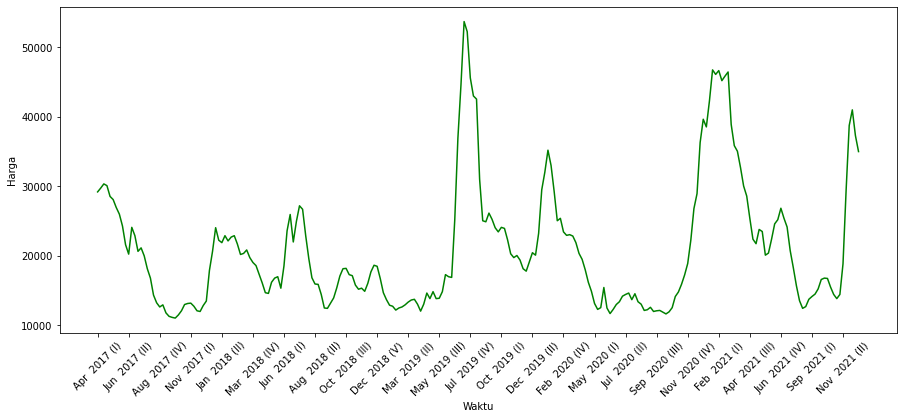

In [5]:
plt.figure(figsize=(15,6))
plt.plot(df_copy['Komoditas (Rp)'], df_copy['Jawa Timur'], color='green')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(df_copy.index)-1,10))
plt.show()

In [6]:
sd = statistics.pstdev(df_copy['Jawa Timur'].to_numpy())
meanS = statistics.mean(df_copy['Jawa Timur'].to_numpy())
print("Koefisien Variasi = ",sd/meanS*100,"%")

Koefisien Variasi =  42.83633942239415 %


In [7]:
Dt = df_copy['Jawa Timur']
Dmin = Dt.min()
Dmax = Dt.max()
N = Dt.count()
Z1 = 950
Z2 = 400

print(Dmin, Dmax, N)

11050 53700 246


In [8]:
R = Dmax+Z2 - (Dmin-Z1)
print(R)

44000


In [9]:
dif = []
df2 = df_copy

for i in range (N-1):
    dt = df['Jawa Timur'][i]
    dt2 = df['Jawa Timur'][i+1]
    ab = round(abs(dt2-dt),2)
    df2.at[i, '|Dt+1 - Dt|'] = ab

df2.at[N-1, '|Dt+1 - Dt|'] = 0

In [10]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|
0,Apr 2017 (I),40259,29200,550.0
1,Apr 2017 (II),39954,29750,600.0
2,Apr 2017 (III),37914,30350,250.0
3,Apr 2017 (IV),35500,30100,1550.0
4,May 2017 (V),36431,28550,450.0
...,...,...,...,...
241,Nov 2021 (III),42500,29400,9350.0
242,Nov 2021 (IV),52452,38750,2250.0
243,Dec 2021 (I),55765,41000,3700.0
244,Dec 2021 (II),57492,37300,2300.0


In [11]:
mean = (sum(df2['|Dt+1 - Dt|']))/(N-1)
print(mean)

1624.4897959183672


In [12]:
K = mean/2
if(K<1):
    K = round(K,1)
else:
    K = math.ceil(K)

print(K)

813


In [13]:
n = math.ceil(R/K)
print(n)

55


In [14]:
himpFuzzy = pd.DataFrame()
ui = []
batasBawah = []
batasAtas = []
Ai = []
ui.append('u1')
Ai.append('A1')
batasBawah.append(Dmin-Z1)
batasAtas.append(batasBawah[0] + K)

for i in range(1, n):
    ui.append('u'+str(i+1))
    Ai.append('A'+str(i+1))
    batasBawah.append(batasAtas[i-1])
    batasAtas.append(batasBawah[i] + K)

himpFuzzy['ui'] = ui
himpFuzzy['Ai'] = Ai
himpFuzzy['batas bawah'] = batasBawah
himpFuzzy['batas atas'] = batasAtas

In [15]:
himpFuzzy['mi'] = (himpFuzzy['batas bawah'] + himpFuzzy['batas atas'])/2

In [16]:
himpFuzzy

,ui,Ai,batas bawah,batas atas,mi
0,u1,A1,10100,10913,10506.5
1,u2,A2,10913,11726,11319.5
2,u3,A3,11726,12539,12132.5
3,u4,A4,12539,13352,12945.5
4,u5,A5,13352,14165,13758.5
5,u6,A6,14165,14978,14571.5
6,u7,A7,14978,15791,15384.5
7,u8,A8,15791,16604,16197.5
8,u9,A9,16604,17417,17010.5
9,u10,A10,17417,18230,17823.5


In [17]:
# FLR dan FLRG
data = df2['Jawa Timur']

hasilFuzzy = []
for i in data:
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= i 
    cond2 = copyHimp['batas atas'] >= i 
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    hasilFuzzy.append(fuzzyfikasi)

df2['fuzzyfikasi'] = hasilFuzzy

In [18]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi
0,Apr 2017 (I),40259,29200,550.0,A24
1,Apr 2017 (II),39954,29750,600.0,A25
2,Apr 2017 (III),37914,30350,250.0,A25
3,Apr 2017 (IV),35500,30100,1550.0,A25
4,May 2017 (V),36431,28550,450.0,A23
...,...,...,...,...,...
241,Nov 2021 (III),42500,29400,9350.0,A24
242,Nov 2021 (IV),52452,38750,2250.0,A36
243,Dec 2021 (I),55765,41000,3700.0,A39
244,Dec 2021 (II),57492,37300,2300.0,A34


In [19]:
nextState = []
for k in range(0, len(df2.index)-1):
    neSt = df2['fuzzyfikasi'].iloc[k+1]
    nextState.append(neSt)

df2['next state'] = pd.Series(nextState)

In [20]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state
0,Apr 2017 (I),40259,29200,550.0,A24,A25
1,Apr 2017 (II),39954,29750,600.0,A25,A25
2,Apr 2017 (III),37914,30350,250.0,A25,A25
3,Apr 2017 (IV),35500,30100,1550.0,A25,A23
4,May 2017 (V),36431,28550,450.0,A23,A23
...,...,...,...,...,...,...
241,Nov 2021 (III),42500,29400,9350.0,A24,A36
242,Nov 2021 (IV),52452,38750,2250.0,A36,A39
243,Dec 2021 (I),55765,41000,3700.0,A39,A34
244,Dec 2021 (II),57492,37300,2300.0,A34,A31


In [21]:
# FLRG
dfFLRG = pd.DataFrame()
dfFLRG['Ai'] = himpFuzzy['Ai']
dfFLRG['FLRG'] = ''

# ambil df2 kecuali baris terakhir karena next statenya kosong
df3 = df2[:-1]

for f in range(len(dfFLRG.index)):
    searchAi = 'A'+str(f+1)
    
    new = df3[df3['fuzzyfikasi'].isin([searchAi])]
    group = new['next state']
    group = group.to_numpy()
    
    if len(group) > 0 :
        dfFLRG['FLRG'][f] = group

In [22]:
dfFLRG

,Ai,FLRG
0,A1,
1,A2,"[A2, A2, A2, A3, A3, A3]"
2,A3,"[A2, A4, A3, A4, A3, A4, A3, A4, A4, A4, A2, A..."
3,A4,"[A4, A4, A3, A4, A4, A4, A3, A5, A5, A4, A3, A..."
4,A5,"[A10, A7, A4, A5, A4, A6, A5, A6, A6, A6, A4, ..."
5,A6,"[A4, A6, A8, A3, A8, A5, A5, A5, A9, A4, A6, A..."
6,A7,"[A11, A9, A7, A6, A3, A5, A8, A6]"
7,A8,"[A6, A9, A8, A6, A7, A10, A6, A9, A9]"
8,A9,"[A6, A8, A9, A7, A8, A10, A9, A8, A6, A9, A9, ..."
9,A10,"[A9, A13, A10, A9, A11, A10, A12, A8]"


In [23]:
# hasil fuzzyfikasi
dfFLRG['defuzzyfikasi'] = ''

for g in range(len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[g]
    flrg = dfFLRG['FLRG'].loc[g]
    hasil = 0

    if (len(flrg) == 0):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == ai]['mi']
        hasil = fuzzyfikasi.values[0]
    
    elif (len(flrg) == 1):
        fuzzyfikasi = himpFuzzy[himpFuzzy['Ai'] == flrg[0]]['mi']
        hasil = fuzzyfikasi.values[0]
        
    else:
        lenFlrg = len(flrg)
        for h in range(len(flrg)):
            mi = himpFuzzy[himpFuzzy['Ai'] == flrg[h]]['mi']
            bobot = (1/len(flrg)) * mi.values[0]
            hasil = hasil + bobot
            

    dfFLRG['defuzzyfikasi'][g] = hasil

In [24]:
dfFLRG

,Ai,FLRG,defuzzyfikasi
0,A1,,10506.5
1,A2,"[A2, A2, A2, A3, A3, A3]",11726.0
2,A3,"[A2, A4, A3, A4, A3, A4, A3, A4, A4, A4, A2, A...",12417.05
3,A4,"[A4, A4, A3, A4, A4, A4, A3, A5, A5, A4, A3, A...",13086.891304
4,A5,"[A10, A7, A4, A5, A4, A6, A5, A6, A6, A6, A4, ...",14215.8125
5,A6,"[A4, A6, A8, A3, A8, A5, A5, A5, A9, A4, A6, A...",14661.833333
6,A7,"[A11, A9, A7, A6, A3, A5, A8, A6]",15282.875
7,A8,"[A6, A9, A8, A6, A7, A10, A6, A9, A9]",16016.833333
8,A9,"[A6, A8, A9, A7, A8, A10, A9, A8, A6, A9, A9, ...",17010.5
9,A10,"[A9, A13, A10, A9, A11, A10, A12, A8]",18026.75


In [25]:
df2['yt'] = ''

for y in range (len(dfFLRG.index)):
    ai = dfFLRG['Ai'].loc[y]
    listAi = df2[df2['fuzzyfikasi'] == ai]
    yt = dfFLRG['defuzzyfikasi'][y]
    
    if len(listAi) > 0:
        idx = listAi.index
        for z in idx:
            df2.at[z+1,'yt'] = yt

In [26]:
df2

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),40259.0,29200.0,550.0,A24,A25,
1,Apr 2017 (II),39954.0,29750.0,600.0,A25,A25,32457.5
2,Apr 2017 (III),37914.0,30350.0,250.0,A25,A25,29205.5
3,Apr 2017 (IV),35500.0,30100.0,1550.0,A25,A23,29205.5
4,May 2017 (V),36431.0,28550.0,450.0,A23,A23,29205.5
...,...,...,...,...,...,...,...
242,Nov 2021 (IV),52452.0,38750.0,2250.0,A36,A39,32457.5
243,Dec 2021 (I),55765.0,41000.0,3700.0,A39,A34,38555.0
244,Dec 2021 (II),57492.0,37300.0,2300.0,A34,A31,37335.5
245,Dec 2021 (III),59748.0,35000.0,0.0,A31,NaN,34896.5


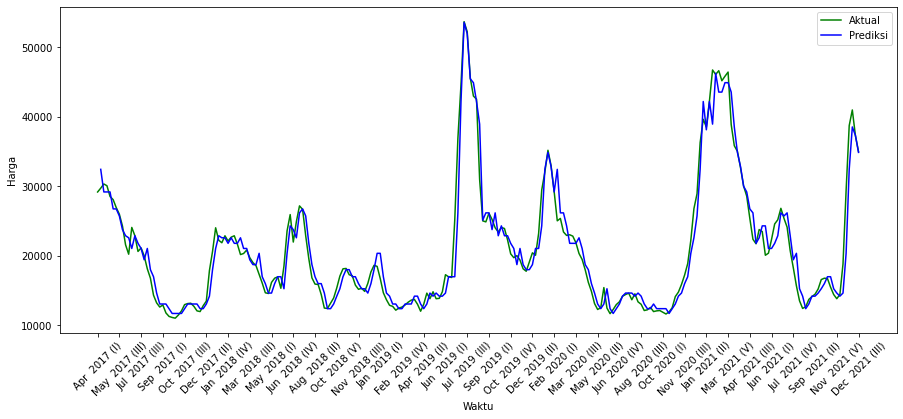

In [27]:
df2_copy = df2.copy()
df2_copy = df2_copy.drop(index=df2_copy.index[-1])
df2_copy.reset_index(inplace=True, drop=True)
df2_copy
plt.figure(figsize=(15,6))
plt.plot(df2_copy['Komoditas (Rp)'], df2_copy['Jawa Timur'], color='green', label='Aktual')
plt.plot(df2_copy['Komoditas (Rp)'][1:], df2_copy['yt'][1:], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,len(df2_copy.index),7))
plt.legend()
plt.show()

In [28]:
# MAPE
y_actual = df2['Jawa Timur'][1:-1].to_numpy()
y_predict = df2['yt'][1:-1].to_numpy()

# MAE
MAE = mean_absolute_error(y_actual, y_predict)
print("MAE = ",MAE)

# Root MSE squared=False
RMSE = mean_squared_error(y_actual, y_predict, squared=False)
print("RMSE = ",RMSE)

MAPE = mean_absolute_percentage_error(y_actual, y_predict)
print("MAPE = ",MAPE*100)

MAE =  1336.455725617181
RMSE =  2070.650404683747
MAPE =  6.487866938936228


In [29]:
lastIndex = len(df2.index)
dfPredictNext = df2

for n in range (nPred-1):
    # Add fuzzyfikai dr hasil predict
    nilaiYt = dfPredictNext['yt'][lastIndex-1+n]
    
    copyHimp = himpFuzzy
    cond1 = copyHimp['batas bawah'] <= nilaiYt
    cond2 = copyHimp['batas atas'] >= nilaiYt
    dfAi = copyHimp.where(cond1 & cond2) 
    dfAi = dfAi[~dfAi['ui'].isna()]
    fuzzyfikasi = dfAi['Ai'].iloc[0]
    dfPredictNext.at[lastIndex + n-1, 'fuzzyfikasi'] = fuzzyfikasi

    # add predict
    yt = dfFLRG['defuzzyfikasi'][dfFLRG['Ai'] == fuzzyfikasi]
    dfPredictNext.at[lastIndex+n, 'yt'] = yt.values[0]    

In [30]:
dfPredictNext

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
0,Apr 2017 (I),40259.0,29200.0,550.0,A24,A25,
1,Apr 2017 (II),39954.0,29750.0,600.0,A25,A25,32457.5
2,Apr 2017 (III),37914.0,30350.0,250.0,A25,A25,29205.5
3,Apr 2017 (IV),35500.0,30100.0,1550.0,A25,A23,29205.5
4,May 2017 (V),36431.0,28550.0,450.0,A23,A23,29205.5
...,...,...,...,...,...,...,...
302,NaN,NaN,NaN,NaN,A24,NaN,29205.5
303,NaN,NaN,NaN,NaN,A28,NaN,32457.5
304,NaN,NaN,NaN,NaN,A25,NaN,30018.5
305,NaN,NaN,NaN,NaN,A24,NaN,29205.5


In [31]:
dfPredictNext[len(dfPredictNext.index)-nPred:]

,Komoditas (Rp),Semua Provinsi,Jawa Timur,|Dt+1 - Dt|,fuzzyfikasi,next state,yt
246,NaN,NaN,NaN,NaN,A28,NaN,32864.0
247,NaN,NaN,NaN,NaN,A25,NaN,30018.5
248,NaN,NaN,NaN,NaN,A24,NaN,29205.5
249,NaN,NaN,NaN,NaN,A28,NaN,32457.5
250,NaN,NaN,NaN,NaN,A25,NaN,30018.5
...,...,...,...,...,...,...,...
302,NaN,NaN,NaN,NaN,A24,NaN,29205.5
303,NaN,NaN,NaN,NaN,A28,NaN,32457.5
304,NaN,NaN,NaN,NaN,A25,NaN,30018.5
305,NaN,NaN,NaN,NaN,A24,NaN,29205.5


In [32]:
df_result = df.copy()
df_result['yt'] = df2['yt']
df_result

,Komoditas (Rp),Semua Provinsi,Jawa Timur,yt
0,Apr 2017 (I),40259,29200,
1,Apr 2017 (II),39954,29750,32457.5
2,Apr 2017 (III),37914,30350,29205.5
3,Apr 2017 (IV),35500,30100,29205.5
4,May 2017 (V),36431,28550,29205.5
...,...,...,...,...
302,Jan 2023 (IV),40269,29900,29205.5
303,Feb 2023 (I),40657,31450,32457.5
304,Feb 2023 (II),42054,32450,30018.5
305,Feb 2023 (III),43128,33250,29205.5


In [33]:
df_result[len(df_result.index)-nPred:]

,Komoditas (Rp),Semua Provinsi,Jawa Timur,yt
246,Dec 2021 (IV),58662,33400,32864.0
247,Jan 2022 (I),54180,29500,30018.5
248,Jan 2022 (II),51093,27800,29205.5
249,Jan 2022 (III),47791,23650,32457.5
250,Jan 2022 (IV),45206,22700,30018.5
...,...,...,...,...
302,Jan 2023 (IV),40269,29900,29205.5
303,Feb 2023 (I),40657,31450,32457.5
304,Feb 2023 (II),42054,32450,30018.5
305,Feb 2023 (III),43128,33250,29205.5


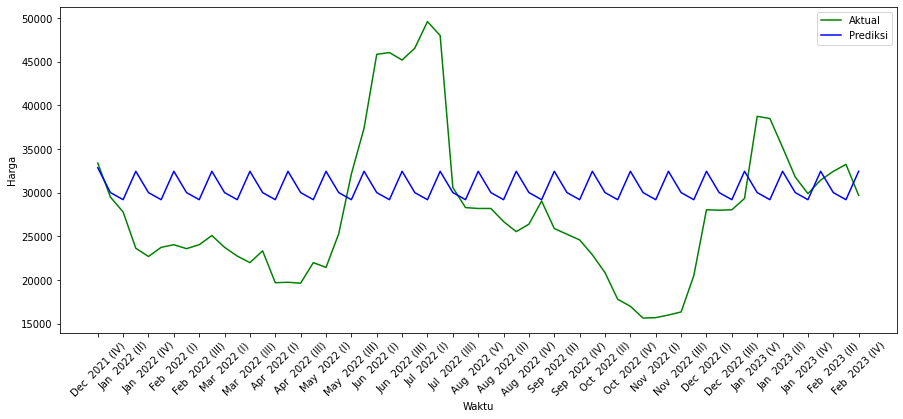

In [34]:
plt.figure(figsize=(15,6))
plt.plot(df_result['Komoditas (Rp)'][len(df_result.index)-nPred:], df_result['Jawa Timur'][len(df_result.index)-nPred:], color='green', label='Aktual')
plt.plot(df_result['Komoditas (Rp)'][len(df_result.index)-nPred:], df_result['yt'][len(df_result.index)-nPred:], color='blue', label='Prediksi')
plt.xlabel('Waktu')
plt.ylabel('Harga')
plt.xticks(rotation=45)
plt.xticks(np.arange(0,nPred,2))
plt.legend()
plt.show()

In [35]:
# MAPE pred
y_actualpred = df_result['Jawa Timur'][last-nPred:len(df_result.index)].to_numpy()
y_predictpred = df_result['yt'][last-nPred:len(df_result.index)].to_numpy()

# MAPE
MAPE2 = mean_absolute_percentage_error(y_actualpred, y_predictpred)
# Root MSE squared=False
RMSE2 = mean_squared_error(y_actualpred, y_predictpred, squared=False)
# MAE
MAE2 = mean_absolute_error(y_actualpred, y_predictpred)

print("Hasil MAPE untuk memprediksi data",nPred,"periode kedepan")
print("MAE = ",MAE2)
print("RMSE = ",RMSE2)
print("MAPE = ",MAPE2*100)

Hasil MAPE untuk memprediksi data 61 periode kedepan
MAE =  7142.098360655737
RMSE =  8767.229707136967
MAPE =  28.9060153598592


In [36]:
# MAPE all
y_actual2 = df_result['Jawa Timur'][1:len(df_result.index)].to_numpy()
# print(y_actual2)
y_predict2 = df_result['yt'][1:len(df_result.index)].to_numpy()
# MAPE
MAPE3 = mean_absolute_percentage_error(y_actual2, y_predict2)
# Root MSE squared=False
RMSE3 = mean_squared_error(y_actual2, y_predict2, squared=False)
# MAE
MAE3 = mean_absolute_error(y_actual2, y_predict2)
print("MAE = ",MAE3)
print("RMSE = ",RMSE3)
print("MAPE = ",MAPE3*100)

MAE =  2493.7897149549326
RMSE =  4330.762295392124
MAPE =  10.956844238531986
